# Density approximation of $V_Y$

In [1]:
from pearsondist import Pearson8, Support8

from utils import plot_pdf_cdf, plot_dpdf_pdf
from joint_mom import comp_joint_moms_mat
from joint_mom_tr import joint_mom_tr, joint_mom_tr_row, index
import numpy as np

In [2]:
jointMomRow = np.loadtxt('hest1_mu_vy_row.txt', delimiter=' ', dtype=float).tolist()

In [3]:
degree = 4
mu_d1 = [joint_mom_tr_row(i, 0, jointMomRow) for i in range(1, 2*degree + 1)]
mu_x2 = [jointMomRow[index(0, i)] for i in range(1, 2*degree + 1)]
mu_d2 = [joint_mom_tr_row(0, i, jointMomRow) for i in range(1, 2*degree + 1)]
mu_d1d2 = [[joint_mom_tr_row(i, j, jointMomRow) for j in range(degree + 1)] for i in range(degree + 1)]

## Pearson Density Approximation ($\zeta_1 = x_1$): $V_t$

{'A1': np.float64(0.36581564095661784),
 'A2': np.float64(-4262.600731680587),
 'A3': np.float64(4262.234916039636),
 'B3': np.float64(3196918.7470919583),
 'type': 44,
 'x1': np.float64(-5.726822286065462e-16),
 'x2': np.float64(393.3317012774519),
 'x3': np.complex128(-178.34572464698272+331.39827480140286j)}
a = 0.010949560101660892, scale = -3437.811896214025
is_max: False
pdf(-a) = 1.0000000


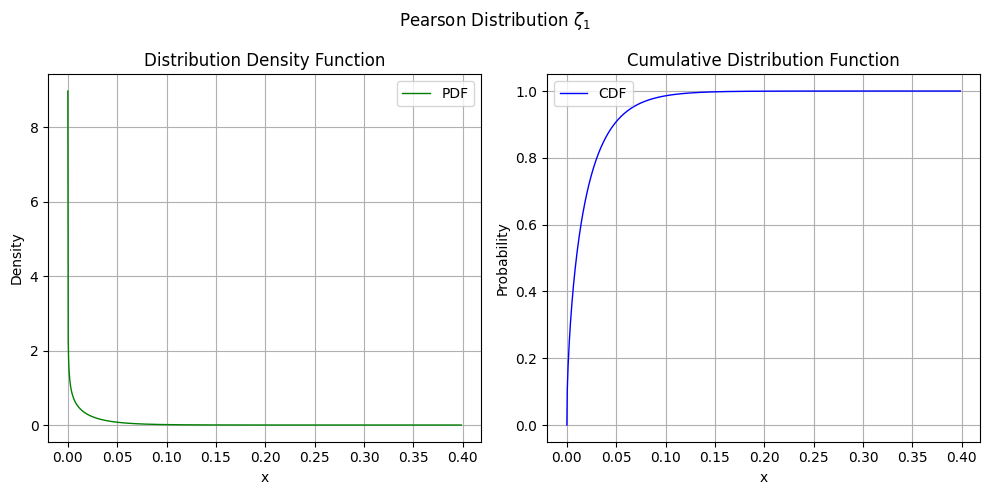

pdf(0.0000100) = 8.97e+00, pdf(0.3984790) = 3.08e-07


In [4]:
from pprint import pprint

pearson = Pearson8(mu_d1)
pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
print(f'is_max: {pearson.pdf_obj.is_max}')
print(f'pdf(-a) = {pearson.pdf(-pearson.coef[0]):.7f}')
# lbub = pearson.determine_bounds()

lbub = (0.00001, 0.398479)
# lbub = (-0.05, 0.3)
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_1$'
plot_pdf_cdf(x, pdf, title)
dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
# support8 = Support8(pearson.pdf_obj)
# bounds = support8.determine_bounds()
# print(f'bounds: ({bounds[0]:.5f},{bounds[1]:.5f})')

# roots = support8.pdf_obj.ddpdf_roots()
# plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Pearson Density Approximation ($x_2$): $Y_t$

{'A1': np.float64(-4.271230544900436),
 'A2': np.float64(4.271230544900436),
 'B1': np.float64(-17.770014216873307),
 'B2': np.float64(-0.21487365095444208),
 'type': 42,
 'x1': np.complex128(-1.8664105554920103+1.3438759132302256j),
 'x2': np.complex128(0.2389414828451036+0.15412578836450733j)}
a = -0.08595450142445907, scale = 21.352109823711757
iteration: 0, x0 =   -0.0911294
iteration: 1, x0 =   -0.2152258
iteration: 2, x0 =   -0.3308536
iteration: 3, x0 =   -0.4471219
iteration: 4, x0 =   -0.5654853
iteration: 5, x0 =   -0.6858267
iteration: 6, x0 =   -0.8075515
iteration: 7, x0 =   -0.9299944
iteration: 0, x0 =    0.2598214
iteration: 1, x0 =    0.2892255
iteration: 2, x0 =    0.3170956
iteration: 3, x0 =    0.3454652
iteration: 4, x0 =    0.3757299
iteration: 5, x0 =    0.4091795
iteration: 6, x0 =    0.4472433
iteration: 7, x0 =    0.4916855
iteration: 8, x0 =    0.5448342
iteration: 9, x0 =    0.6099133
iteration: 10, x0 =    0.6915807


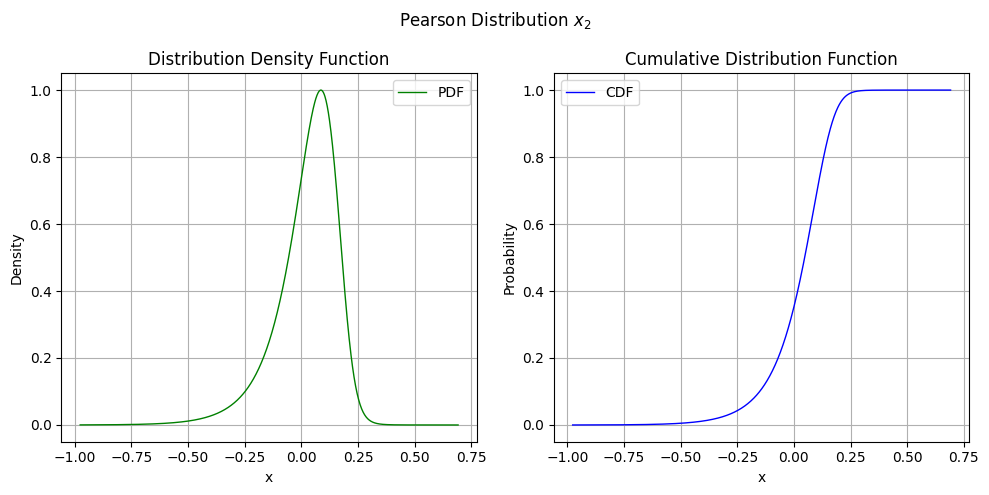

iteration: 0, x0 =   -0.0911294
iteration: 1, x0 =   -0.2152258
iteration: 2, x0 =   -0.3308536
iteration: 3, x0 =   -0.4471219
iteration: 4, x0 =   -0.5654853
iteration: 5, x0 =   -0.6858267
iteration: 6, x0 =   -0.8075515
iteration: 7, x0 =   -0.9299944
iteration: 0, x0 =    0.2598214
iteration: 1, x0 =    0.2892255
iteration: 2, x0 =    0.3170956
iteration: 3, x0 =    0.3454652
iteration: 4, x0 =    0.3757299
iteration: 5, x0 =    0.4091795
iteration: 6, x0 =    0.4472433
iteration: 7, x0 =    0.4916855
iteration: 8, x0 =    0.5448342
iteration: 9, x0 =    0.6099133
iteration: 10, x0 =    0.6915807


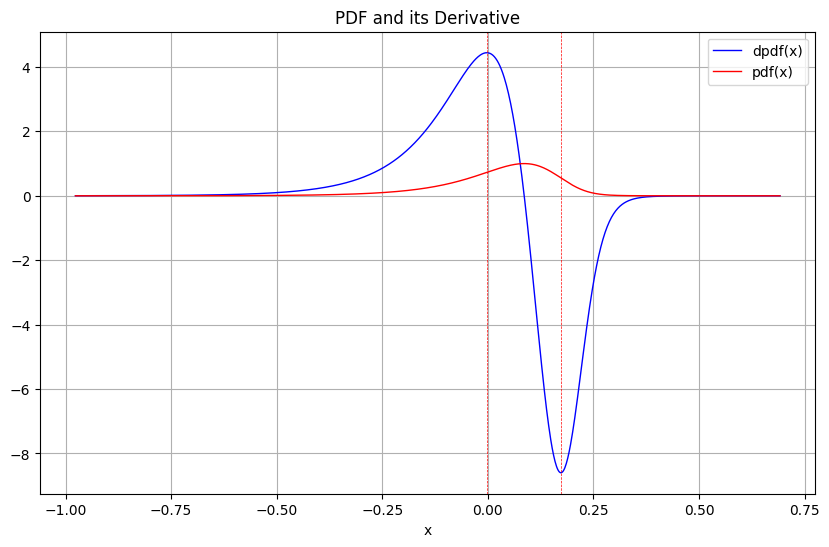

pdf(-0.9765490) = 2.33e-04, pdf(0.6915807) = 4.84e-06


In [5]:
from pearsondist.pearson8 import Pearson8

pearson = Pearson8(mu_x2)

pprint(pearson.pfd) # print(pearson.mom)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()

# lbub = (-1.8, 1.0)
x = np.linspace(lbub[0], lbub[1], 1000)

# txt = ','.join(f'{mu_:.9f}' for mu_ in mu_x2); print(f'mu_x2 = [{txt}]')

pdf = pearson.pdf(x); title = r'Pearson Distribution $x_2$'
plot_pdf_cdf(x, pdf, title)

dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')

## Pearson Density Approximation ($\zeta_2$): $Y_t + c V_t$

The transformed variable $\zeta_2 = Y_t + c V_t$,

$c = -\frac{\mathrm{cov}(I_t, dI\!E_t)}{\mathrm{var}(I_t)} = -0.2825008$

$\mathrm{cov}(\zeta_1, \zeta_2) = \mathrm{cov}(I_t, dI\!E_t + c I_t) = \mathrm{cov}(I_t, dI\!E_t) + c \times\mathrm{var}(I_t) = 0$

{'A1': np.float64(-4.6516782816228055),
 'A2': np.float64(4.6516782816228055),
 'B1': np.float64(-21.414374025147335),
 'B2': np.float64(-0.4010769436990568),
 'type': 42,
 'x1': np.complex128(-2.1012943048175576+1.2737503188013402j),
 'x2': np.complex128(0.24360678765822685+0.16438858868036793j)}
a = -0.11723566791784976, scale = 24.198363781175566
iteration: 0, x0 =   -0.0479870
iteration: 1, x0 =   -0.1566695
iteration: 2, x0 =   -0.2580696
iteration: 3, x0 =   -0.3603910
iteration: 4, x0 =   -0.4651714
iteration: 5, x0 =   -0.5724379
iteration: 6, x0 =   -0.6816450
iteration: 7, x0 =   -0.7920255
iteration: 0, x0 =    0.2797782
iteration: 1, x0 =    0.3146654
iteration: 2, x0 =    0.3479266
iteration: 3, x0 =    0.3822992
iteration: 4, x0 =    0.4196187
iteration: 5, x0 =    0.4616213
iteration: 6, x0 =    0.5102928
iteration: 7, x0 =    0.5681574
iteration: 8, x0 =    0.6386409
iteration: 9, x0 =    0.7266290
iteration: 10, x0 =    0.8394274
lbub: [np.float64(-0.8741005882384422),

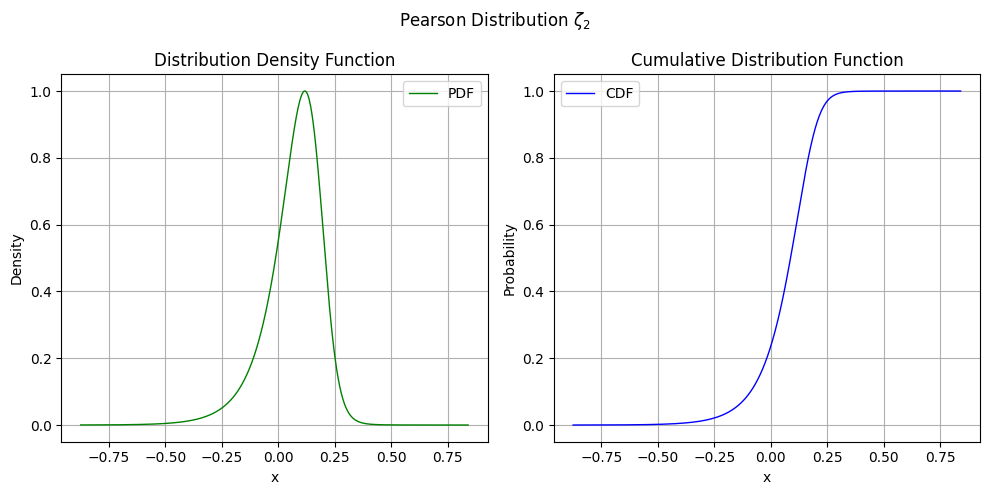

iteration: 0, x0 =   -0.0479870
iteration: 1, x0 =   -0.1566695
iteration: 2, x0 =   -0.2580696
iteration: 3, x0 =   -0.3603910
iteration: 4, x0 =   -0.4651714
iteration: 5, x0 =   -0.5724379
iteration: 6, x0 =   -0.6816450
iteration: 7, x0 =   -0.7920255
iteration: 0, x0 =    0.2797782
iteration: 1, x0 =    0.3146654
iteration: 2, x0 =    0.3479266
iteration: 3, x0 =    0.3822992
iteration: 4, x0 =    0.4196187
iteration: 5, x0 =    0.4616213
iteration: 6, x0 =    0.5102928
iteration: 7, x0 =    0.5681574
iteration: 8, x0 =    0.6386409
iteration: 9, x0 =    0.7266290
iteration: 10, x0 =    0.8394274


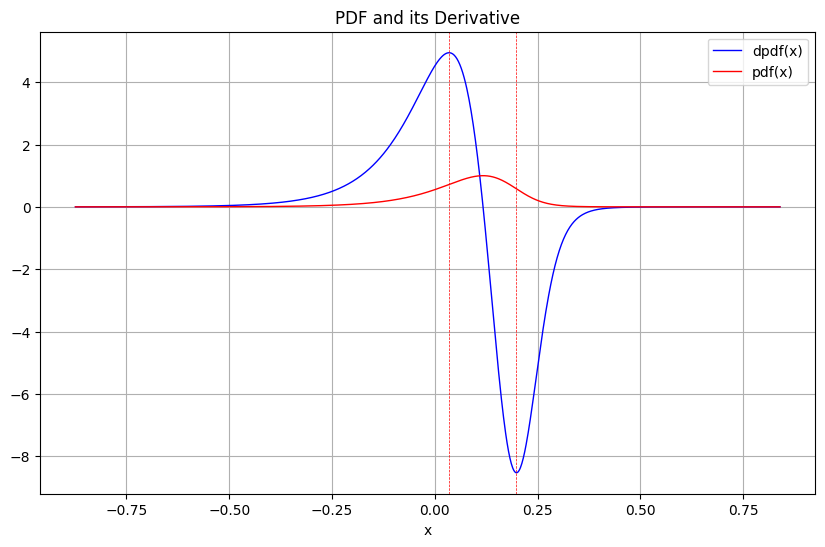

pdf(-0.8741006) = 1.57e-04, pdf(0.8394274) = 8.13e-06


In [6]:
pearson = Pearson8(mu_d2)
pprint(pearson.pfd)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}') # print("coef: ", pearson.coef)
lbub = pearson.determine_bounds()

# lbub = (-1.778969, 0.95)
print(f'lbub: {lbub}')
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_2$'
plot_pdf_cdf(x, pdf, title)

dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'
support8 = Support8(pearson.pdf_obj); roots = support8.pdf_obj.ddpdf_roots()
plot_dpdf_pdf(x, dpdf, pdf, title, roots)

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')